# Exploração inicial — seca por UF e mês (Monitor de Secas / ANA)

Objetivo: a primeira olhada em `seca_uf_mes.parquet` — o que é uma linha, a escala de cada
indicador (head e percentis) e por que 36% das linhas estão vazias sem que isso seja um defeito.

Fonte: `data/interim/seca_uf_mes.parquet`, produzido por
[agrega_uf_mes.py](../src/coleta/monitor_secas/agrega_uf_mes.py) — ticket
[T-015](../tickets/01-coleta/T-015-monitor-secas.md). Os dados vêm da API REST do Monitor de
Secas da ANA, uma requisição por UF.

## A pergunta que este notebook responde

> *Por que um terço da tabela está em branco?*

Porque o Monitor de Secas **não cobria o Brasil inteiro desde o começo**. Ele nasceu em 2014 como
um programa do Nordeste e foi se expandindo estado a estado até fechar o país. A coluna
`monitorado` marca exatamente isso: `False` quer dizer "a UF ainda não fazia parte do programa",
não "não houve seca".

Essa é a restrição que define como o dataset pode ser usado. Um painel nacional só existe a
partir de **2024**; antes disso, o que existe é um painel do Nordeste com companhia crescente.

Percurso: head e schema (1), a chave e a expansão do monitoramento (2), a escala cumulativa e
seus percentis (3), o padrão dos nulos (4), a grande seca do Nordeste como validação (5),
redundância entre indicadores (6).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CAMINHO = Path("..") / "data" / "interim" / "seca_uf_mes.parquet"

df = pd.read_parquet(CAMINHO)
df["data"] = pd.to_datetime(df["ano_mes"])

print(f"{len(df):,} linhas x {df.shape[1] - 1} colunas")
df.head()

3,726 linhas x 14 colunas


,sigla_uf,ano_mes,pct_area_S0plus,pct_area_S2plus,pct_area_S3plus,severidade_media,meses_consecutivos_S2plus,ano,mes,pct_area_S1plus,pct_area_S4plus,severidade_media_area_seca,monitorado,inconsistente,data
0,AC,2015-01,NaN,NaN,NaN,NaN,<NA>,2015,1,NaN,NaN,NaN,False,False,2015-01-01
1,AC,2015-02,NaN,NaN,NaN,NaN,<NA>,2015,2,NaN,NaN,NaN,False,False,2015-02-01
2,AC,2015-03,NaN,NaN,NaN,NaN,<NA>,2015,3,NaN,NaN,NaN,False,False,2015-03-01
3,AC,2015-04,NaN,NaN,NaN,NaN,<NA>,2015,4,NaN,NaN,NaN,False,False,2015-04-01
4,AC,2015-05,NaN,NaN,NaN,NaN,<NA>,2015,5,NaN,NaN,NaN,False,False,2015-05-01


As primeiras linhas já mostram o assunto do notebook: **AC em 2015 é tudo `NaN`**, com
`monitorado = False`. O Acre só entrou no Monitor em novembro de 2022.

---
## 1. Schema: o que é uma linha, e o que significa "S2"

Uma linha é **uma UF num mês**. As medidas se dividem em três famílias:

* **`pct_area_S*plus`** — o percentual do território da UF em cada nível de seca. São
  **cumulativas**: `S2plus` significa "área em seca grave **ou pior**", já incluindo S3 e S4.
* **`severidade_*`** — dois índices de 0 a 5 que resumem as cinco faixas num número só.
* **`monitorado` / `inconsistente`** — flags de qualidade, não medidas.

A escala do Monitor de Secas, do mais fraco ao mais severo:

| Nível | Nome | Leitura |
|---|---|---|
| S0 | seca fraca | áreas entrando ou saindo da seca |
| S1 | seca moderada | algum dano a culturas e pastagens |
| S2 | seca grave | perdas prováveis, restrição de água |
| S3 | seca extrema | perdas generalizadas |
| S4 | seca excepcional | emergência, escassez em reservatórios |

In [2]:
df.drop(columns="data").info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3726 entries, 0 to 3725
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   sigla_uf                    3726 non-null   object 
 1   ano_mes                     3726 non-null   object 
 2   pct_area_S0plus             2368 non-null   float64
 3   pct_area_S2plus             2368 non-null   float64
 4   pct_area_S3plus             2368 non-null   float64
 5   severidade_media            2368 non-null   float64
 6   meses_consecutivos_S2plus   2368 non-null   Float64
 7   ano                         3726 non-null   int64  
 8   mes                         3726 non-null   int64  
 9   pct_area_S1plus             2368 non-null   float64
 10  pct_area_S4plus             2368 non-null   float64
 11  severidade_media_area_seca  2239 non-null   float64
 12  monitorado                  3726 non-null   bool   
 13  inconsistente               3726 

In [3]:
DICIONARIO = {
    "sigla_uf": ("—", "chave", "UF (27 unidades)"),
    "ano_mes": ("mês", "chave", "mês de referência, texto YYYY-MM"),
    "ano": ("ano", "derivada", "componente de ano_mes"),
    "mes": ("1-12", "derivada", "componente de ano_mes"),
    "pct_area_S0plus": ("%", "cumulativa", "área em seca fraca ou pior"),
    "pct_area_S1plus": ("%", "cumulativa", "área em seca moderada ou pior"),
    "pct_area_S2plus": ("%", "cumulativa", "área em seca grave ou pior — o corte usual de dano"),
    "pct_area_S3plus": ("%", "cumulativa", "área em seca extrema ou pior"),
    "pct_area_S4plus": ("%", "cumulativa", "área em seca excepcional"),
    "severidade_media": ("0-5", "índice", "severidade sobre a UF inteira; 0 no mês sem seca"),
    "severidade_media_area_seca": ("1-5", "índice", "severidade só dentro da área seca; NaN se não há seca"),
    "meses_consecutivos_S2plus": ("meses", "contagem", "meses seguidos com alguma área em seca grave+"),
    "monitorado": ("bool", "qualidade", "False = UF fora do programa naquele mês"),
    "inconsistente": ("bool", "qualidade", "True se falha a monotonia cumulativa"),
}

pd.DataFrame(
    [(c, u, f, d) for c, (u, f, d) in DICIONARIO.items()],
    columns=["coluna", "unidade", "tipo", "o que é"],
).set_index("coluna")

,unidade,tipo,o que é
coluna,,,
sigla_uf,—,chave,UF (27 unidades)
ano_mes,mês,chave,"mês de referência, texto YYYY-MM"
ano,ano,derivada,componente de ano_mes
mes,1-12,derivada,componente de ano_mes
pct_area_S0plus,%,cumulativa,área em seca fraca ou pior
pct_area_S1plus,%,cumulativa,área em seca moderada ou pior
pct_area_S2plus,%,cumulativa,área em seca grave ou pior — o corte usual de ...
pct_area_S3plus,%,cumulativa,área em seca extrema ou pior
pct_area_S4plus,%,cumulativa,área em seca excepcional


In [4]:
print("UFs      :", df["sigla_uf"].nunique())
print("meses    :", df["ano_mes"].nunique(), f'({df["ano_mes"].min()} → {df["ano_mes"].max()})')
print("duplicatas (UF, mês)   :", int(df.duplicated(["sigla_uf", "ano_mes"]).sum()))

esperado = df["sigla_uf"].nunique() * df["ano_mes"].nunique()
print(f"grid 27 x 138          : {esperado:,}  |  observado: {len(df):,}  |  completo: {esperado == len(df)}")

UFs      : 27
meses    : 138 (2015-01 → 2026-06)
duplicatas (UF, mês)   : 0
grid 27 x 138          : 3,726  |  observado: 3,726  |  completo: True


O grid é **retangular e perfeito**: existe uma linha para cada UF em cada um dos 138 meses, sem
duplicata. O que falta não é linha — é **valor**. Essa distinção é o que torna a coluna
`monitorado` necessária: sem ela, `NaN` seria ambíguo entre "não medido" e "sem seca".

---
## 2. A expansão do monitoramento

Esta é a característica estrutural mais importante do dataset, e ela não aparece em nenhum
`describe`.

In [5]:
print("monitorado :", df["monitorado"].value_counts().to_dict())
print(f"             {df['monitorado'].mean() * 100:.1f}% das linhas têm dado")
print("inconsistente:", df["inconsistente"].value_counts().to_dict())

monitorado : {True: 2368, False: 1358}
             63.6% das linhas têm dado
inconsistente: {False: 3726}


Nenhuma linha marcada como inconsistente — a violação de monotonia que o coletor sabe detectar
(MA em 2014-11, documentada no README do T-015) cai **fora** da janela de 2015 em diante. Vale
conferir a monotonia diretamente, já que é a premissa de leitura de toda a tabela.

In [6]:
d = df[df["monitorado"]]
viola = (
    (d["pct_area_S0plus"] < d["pct_area_S1plus"])
    | (d["pct_area_S1plus"] < d["pct_area_S2plus"])
    | (d["pct_area_S2plus"] < d["pct_area_S3plus"])
    | (d["pct_area_S3plus"] < d["pct_area_S4plus"])
)
print(f"linhas monitoradas                      : {len(d):,}")
print(f"violações de S0 >= S1 >= S2 >= S3 >= S4 : {int(viola.sum())}")
print(f"valores fora de [0, 100]                : {int((d[[c for c in d if c.startswith('pct_')]].lt(0) | d[[c for c in d if c.startswith('pct_')]].gt(100)).sum().sum())}")

linhas monitoradas                      : 2,368
violações de S0 >= S1 >= S2 >= S3 >= S4 : 0
valores fora de [0, 100]                : 0


Zero violações em 2.368 linhas. A leitura cumulativa está confirmada pelo próprio dado — se as
colunas fossem faixas exclusivas, ordenação perfeita em todas as linhas seria impossível.

In [7]:
inicio = df[df["monitorado"]].groupby("sigla_uf")["ano_mes"].min().sort_values()
inicio.to_frame("primeiro mês monitorado")

,primeiro mês monitorado
sigla_uf,
AL,2015-01
SE,2015-01
RN,2015-01
BA,2015-01
CE,2015-01
PI,2015-01
PE,2015-01
MA,2015-01
PB,2015-01


A cronologia conta a história do programa:

* **2015-01** — nove UFs, todas do Nordeste: AL, BA, CE, MA, PB, PE, PI, RN, SE. O Monitor nasceu
  como resposta à seca do Nordeste.
* **2018–2019** — MG, TO, ES. A expansão começa pelo Sudeste e pelo cerrado.
* **2020** — o grande salto: RJ, GO, DF, MS, PR, RS, SC, SP entram no mesmo ano.
* **2021–2023** — MT, RO, AC, AM, RR, PA, AP. O Norte fecha a lista, com o Amapá em dezembro de
  2023.

In [8]:
cobertura = df.groupby("ano").agg(
    ufs_monitoradas=("monitorado", "sum"),
    linhas=("monitorado", "size"),
)
cobertura["pct"] = (cobertura["ufs_monitoradas"] / cobertura["linhas"] * 100).round(1)
cobertura["ufs_distintas"] = df[df["monitorado"]].groupby("ano")["sigla_uf"].nunique()
cobertura

,ufs_monitoradas,linhas,pct,ufs_distintas
ano,,,,
2015,108,324,33.30,9
2016,108,324,33.30,9
2017,108,324,33.30,9
2018,110,324,34.00,10
2019,130,324,40.10,12
2020,188,324,58.00,20
2021,247,324,76.20,21
2022,260,324,80.20,24
2023,299,324,92.30,27


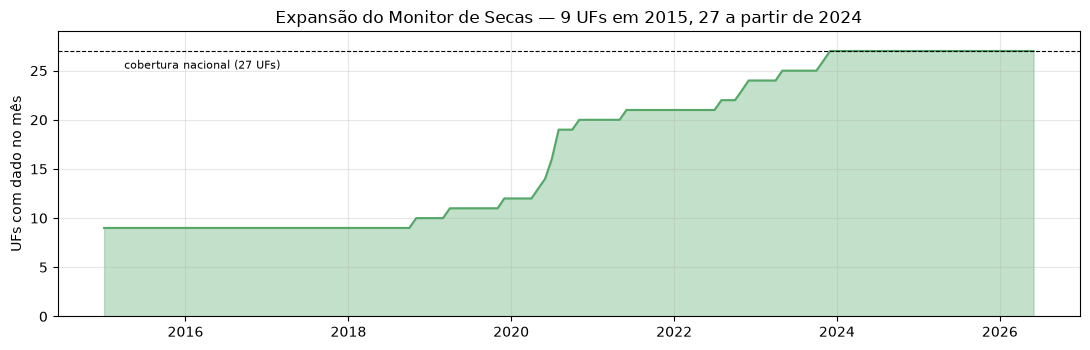

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.6))
serie = df.groupby("data")["monitorado"].sum()
ax.fill_between(serie.index, serie.values, color="#55A868", alpha=0.35)
ax.plot(serie.index, serie.values, color="#55A868")
ax.axhline(27, color="black", lw=0.8, ls="--")
ax.text(serie.index[3], 25.2, "cobertura nacional (27 UFs)", fontsize=8)
ax.set_ylabel("UFs com dado no mês")
ax.set_ylim(0, 29)
ax.set_title("Expansão do Monitor de Secas — 9 UFs em 2015, 27 a partir de 2024")
fig.tight_layout()
plt.show()

O degrau de 2020 é visível a olho nu. **A cobertura nacional só é atingida em 2024** — a partir
daí a série tem 27 UFs em todos os meses.

Consequência direta para a modelagem: uma média nacional de severidade calculada sobre a série
inteira **mede a expansão do programa, não o clima**. Em 2015 a média seria só do Nordeste em
plena seca histórica; em 2024, do país inteiro. A queda aparente não seria melhora climática —
seria diluição amostral. Isso será demonstrado numericamente na seção 5.

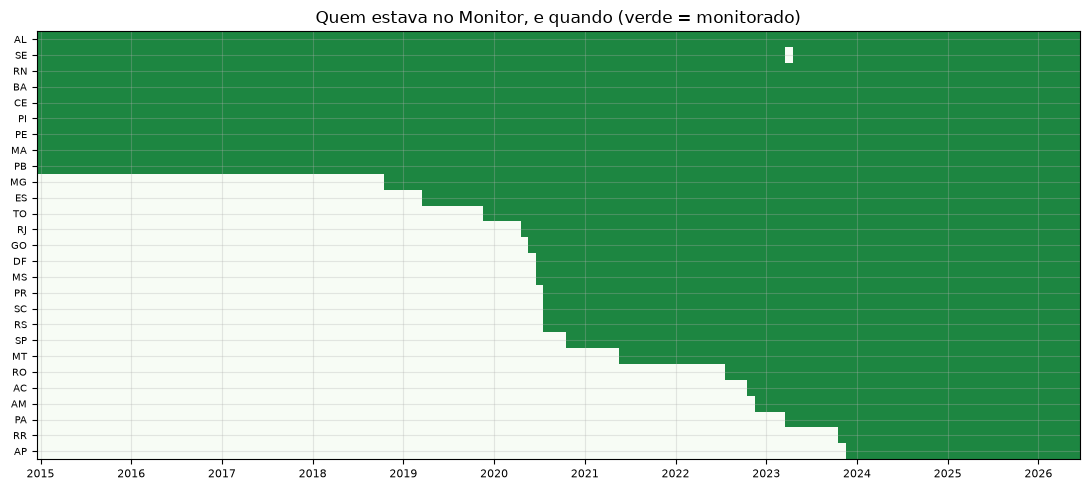

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
mapa = df.pivot_table(index="sigla_uf", columns="data", values="monitorado", aggfunc="first")
mapa = mapa.loc[inicio.index]
ax.imshow(mapa.astype(float), cmap="Greens", aspect="auto", vmin=0, vmax=1.3)
ax.set_yticks(range(len(mapa)), mapa.index, fontsize=7)
passo = 12
ax.set_xticks(range(0, mapa.shape[1], passo), [c.strftime("%Y") for c in mapa.columns[::passo]], fontsize=8)
ax.set_title("Quem estava no Monitor, e quando (verde = monitorado)")
fig.tight_layout()
plt.show()

Repare no traço branco isolado na linha do **SE**: Sergipe tem exatamente **um mês faltando**
(2023-04) no meio de uma série completa desde 2015. É um buraco de publicação da fonte, não uma
saída do programa — o único caso de descontinuidade em toda a tabela.

In [11]:
lacunas = []
for uf, g in df.sort_values("ano_mes").groupby("sigla_uf"):
    m = g["monitorado"].values
    if not m.any():
        continue
    depois_do_inicio = m[m.argmax() :]
    if (~depois_do_inicio).any():
        lacunas.append((uf, g["ano_mes"].values[m.argmax()], list(g.loc[~g["monitorado"], "ano_mes"].values[-int((~depois_do_inicio).sum()) :])))

pd.DataFrame(lacunas, columns=["uf", "inicio", "meses_faltando_depois_do_inicio"])

,uf,inicio,meses_faltando_depois_do_inicio
0,SE,2015-01,[2023-04]


---
## 3. Percentis: a escala dos indicadores

Todos os `pct_area_*` vivem em [0, 100] e todas as severidades em [0, 5], então o `describe` aqui
não serve para achar valor impossível — serve para mostrar **quão assimétrica** é a seca.

Só as linhas monitoradas entram; incluir as demais misturaria "sem dado" com "sem seca".

In [12]:
MEDIDAS = [
    "pct_area_S0plus",
    "pct_area_S1plus",
    "pct_area_S2plus",
    "pct_area_S3plus",
    "pct_area_S4plus",
    "severidade_media",
    "severidade_media_area_seca",
    "meses_consecutivos_S2plus",
]

d[MEDIDAS].astype("float64").describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
pct_area_S0plus,"2,368.00",70.96,33.00,0.00,0.00,47.67,84.89,100.00,100.00,100.00,100.00
pct_area_S1plus,"2,368.00",44.36,37.29,0.00,0.00,3.28,40.77,81.44,100.00,100.00,100.00
pct_area_S2plus,"2,368.00",22.03,30.93,0.00,0.00,0.00,1.83,37.76,89.65,100.00,100.00
pct_area_S3plus,"2,368.00",9.45,22.37,0.00,0.00,0.00,0.00,2.20,70.74,100.00,100.00
pct_area_S4plus,"2,368.00",3.29,12.81,0.00,0.00,0.00,0.00,0.00,26.48,69.79,96.13
severidade_media,"2,368.00",1.50,1.13,0.00,0.00,0.58,1.32,2.19,3.72,4.62,4.96
severidade_media_area_seca,"2,239.00",1.91,0.90,1.00,1.00,1.19,1.67,2.38,3.83,4.64,4.96
meses_consecutivos_S2plus,"2,368.00",10.29,16.63,0.00,0.00,0.00,2.00,14.00,49.00,72.33,89.00


A leitura, do topo da escala para a base:

* **`pct_area_S0plus`** — mediana **84,9%**. Numa UF monitorada típica, a maior parte do
  território está em *alguma* seca. Isso reflete a origem do programa: monitora-se onde há
  problema. Não é uma amostra aleatória do Brasil.
* **`pct_area_S2plus`** (seca grave ou pior) — mediana **1,8%**, p75 = 37,8%, p95 = 89,7%. A
  distância entre mediana e p95 é enorme: seca grave é rara na maioria dos meses e quase total em
  poucos. É a assinatura de uma variável de evento.
* **`pct_area_S3plus` e `S4plus`** — **mediana zero**, e o p75 de S4plus também é zero. Seca
  excepcional é fenômeno de cauda: aparece em menos de 25% dos meses monitorados, mas quando
  aparece chega a 96% do território.
* **`severidade_media`** — mediana 1,32, ou seja, entre seca moderada e grave.
* **`meses_consecutivos_S2plus`** — mediana 2, p95 = **49 meses**. Quatro anos de seca grave
  ininterrupta. Essa cauda é o que distingue seca de chuva: seca é um estado **persistente**,
  não um evento mensal independente.

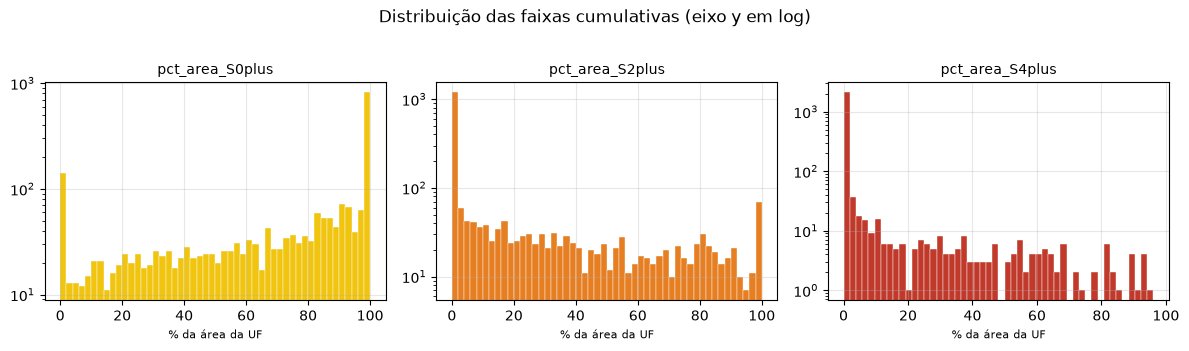

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (col, cor) in zip(
    axes,
    [("pct_area_S0plus", "#F1C40F"), ("pct_area_S2plus", "#E67E22"), ("pct_area_S4plus", "#C0392B")],
):
    ax.hist(d[col].dropna(), bins=50, color=cor, edgecolor="white", linewidth=0.3)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("% da área da UF", fontsize=8)
    ax.set_yscale("log")
fig.suptitle("Distribuição das faixas cumulativas (eixo y em log)", y=1.02)
fig.tight_layout()
plt.show()

As três distribuições são **bimodais nas pontas**: pilha em zero e pilha em 100. Um estado
tende a estar inteiro seco ou inteiro livre — estados intermediários são a minoria. Faz sentido
fisicamente: seca é um fenômeno de escala sinótica, cobre regiões inteiras.

In [14]:
extremos = pd.DataFrame(
    {
        "% dos meses com valor 0": [(d[c] == 0).mean() * 100 for c in MEDIDAS[:5]],
        "% dos meses com valor 100": [(d[c] == 100).mean() * 100 for c in MEDIDAS[:5]],
    },
    index=MEDIDAS[:5],
)
extremos.round(1)

,% dos meses com valor 0,% dos meses com valor 100
pct_area_S0plus,5.40,28.40
pct_area_S1plus,20.50,8.80
pct_area_S2plus,45.90,2.50
pct_area_S3plus,72.20,1.10
pct_area_S4plus,86.80,0.00


Confirmado em número, e o gradiente é nítido: `pct_area_S0plus` é zero em apenas 5,4% dos meses,
enquanto `pct_area_S4plus` é zero em **86,8%**. Quanto mais severa a faixa, mais ela vira um
indicador binário de evento raro — tratar S4 como variável contínua num modelo linear ignora que
ela é zero em quase nove de cada dez meses.

Na outra ponta, `pct_area_S0plus` vale **exatamente 100% em 28,4% dos meses**: saturação no teto.
Nesses meses a coluna não distingue nada — todo o estado está em seca fraca ou pior, e é preciso
olhar as faixas mais severas para saber o quanto.

---
## 4. Os nulos: todos explicados por uma coluna só

Diferente do dataset de clima (notebook 04), aqui a nulidade é **inteiramente estrutural**.

In [15]:
nulos = df.drop(columns="data").isna().sum().to_frame("nulos")
nulos["pct"] = (nulos["nulos"] / len(df) * 100).round(2)
nulos[nulos["nulos"] > 0]

,nulos,pct
pct_area_S0plus,1358,36.45
pct_area_S2plus,1358,36.45
pct_area_S3plus,1358,36.45
severidade_media,1358,36.45
meses_consecutivos_S2plus,1358,36.45
pct_area_S1plus,1358,36.45
pct_area_S4plus,1358,36.45
severidade_media_area_seca,1487,39.91


In [16]:
print("nulos entre as linhas monitoradas:")
print(d.drop(columns="data").isna().sum()[lambda s: s > 0].to_string())
print(f"\nlinhas não monitoradas com algum valor: {int(df[~df['monitorado']][MEDIDAS].notna().any(axis=1).sum())}")

nulos entre as linhas monitoradas:
severidade_media_area_seca    129

linhas não monitoradas com algum valor: 0


O resultado é limpo: entre as 2.368 linhas monitoradas, **a única coluna com nulo é
`severidade_media_area_seca`** (129 casos). E entre as 1.358 não monitoradas, **nenhuma** tem
valor. Ou seja, `monitorado` é uma explicação perfeita, sem exceção nos dois sentidos.

Os 129 nulos restantes também são por construção — vale confirmar.

In [17]:
tabela = pd.crosstab(
    d["severidade_media_area_seca"].isna().rename("severidade_area_seca é NaN"),
    (d["pct_area_S0plus"] == 0).rename("UF sem nenhuma seca"),
)
print(tabela.to_string())
print(f"\nseveridade_media quando não há seca: {d.loc[d['pct_area_S0plus'] == 0, 'severidade_media'].unique()}")

UF sem nenhuma seca         False  True 
severidade_area_seca é NaN              
False                        2239      0
True                            0    129

severidade_media quando não há seca: [0.]


Correspondência exata: `severidade_media_area_seca` é `NaN` **se e somente se** a UF não tem
nenhuma área em seca. É a média de um conjunto vazio — dividir por área seca zero. O `NaN` está
certo e **não deve ser imputado como zero**, porque zero nesta escala significaria "seca de
intensidade nula dentro da área seca", que é contraditório. A coluna irmã `severidade_media`
resolve isso corretamente com **0**, que ali é o valor certo: a UF inteira está sem seca.

Para a modelagem, a regra prática: **`severidade_media` é a coluna segura**, sem nulos entre
linhas monitoradas e com zero bem definido. `severidade_media_area_seca` responde outra pergunta
("quando seca, quão forte?") e carrega nulo por definição.

---
## 5. Validação: a grande seca do Nordeste aparece?

O teste mais forte de que o dado está correto é procurar nele um evento que sabemos ter
acontecido.

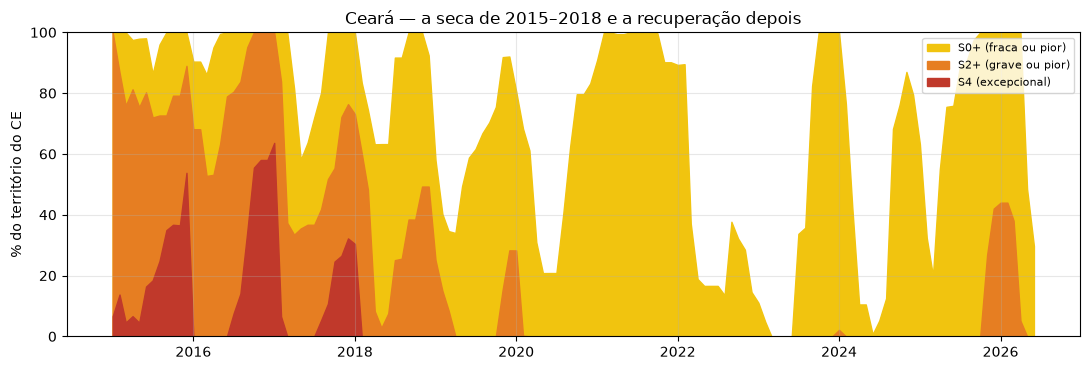

In [18]:
ce = df[(df["sigla_uf"] == "CE") & df["monitorado"]].set_index("data")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(ce.index, ce["pct_area_S0plus"], color="#F1C40F", label="S0+ (fraca ou pior)")
ax.fill_between(ce.index, ce["pct_area_S2plus"], color="#E67E22", label="S2+ (grave ou pior)")
ax.fill_between(ce.index, ce["pct_area_S4plus"], color="#C0392B", label="S4 (excepcional)")
ax.set_ylabel("% do território do CE")
ax.set_ylim(0, 100)
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Ceará — a seca de 2015–2018 e a recuperação depois")
fig.tight_layout()
plt.show()

In [19]:
df[(df["sigla_uf"] == "CE") & df["ano_mes"].isin(["2015-01", "2017-01", "2020-06", "2024-01"])][
    ["ano_mes", "pct_area_S0plus", "pct_area_S2plus", "pct_area_S4plus", "severidade_media", "meses_consecutivos_S2plus"]
].set_index("ano_mes")

,pct_area_S0plus,pct_area_S2plus,pct_area_S4plus,severidade_media,meses_consecutivos_S2plus
ano_mes,,,,,
2015-01,100.00,100.00,6.61,4.03,7.00
2017-01,100.00,100.00,63.64,4.52,31.00
2020-06,20.84,0.00,0.00,0.21,0.00
2024-01,100.00,2.13,0.00,1.78,1.00


O dado reproduz a história com precisão. Em **janeiro de 2017**, 100% do Ceará está em seca grave
ou pior e **63,6% em seca excepcional** — o auge da pior seca do Nordeste em décadas, com
severidade média 4,52 de 5. Em 2015-01 o estado já estava inteiro em seca, mas com apenas 6,6% no
nível excepcional: a crise ainda estava se aprofundando.

Depois de 2018 a área excepcional desaparece e o gráfico mostra a recuperação, com retornos
parciais nos anos seguintes.

In [20]:
piores = df.nlargest(10, "severidade_media")[
    ["sigla_uf", "ano_mes", "pct_area_S0plus", "pct_area_S2plus", "pct_area_S4plus", "severidade_media", "meses_consecutivos_S2plus"]
]
piores.reset_index(drop=True)

,sigla_uf,ano_mes,pct_area_S0plus,pct_area_S2plus,pct_area_S4plus,severidade_media,meses_consecutivos_S2plus
0,PI,2016-12,100.00,100.00,96.13,4.96,30.00
1,PE,2017-01,100.00,100.00,93.60,4.94,31.00
2,PE,2017-02,100.00,100.00,93.55,4.94,32.00
3,PE,2016-11,100.00,100.00,92.78,4.93,29.00
4,PE,2016-12,100.00,100.00,92.78,4.93,30.00
5,PE,2017-03,100.00,100.00,91.20,4.91,33.00
6,PB,2016-11,100.00,100.00,89.59,4.90,29.00
7,PB,2016-12,100.00,100.00,89.59,4.90,30.00
8,PB,2017-01,100.00,100.00,89.59,4.90,31.00
9,PE,2016-10,100.00,100.00,89.94,4.85,28.00


Os dez meses mais severos de toda a base são **PI, PE e PB entre 2016 e 2017** — todos com 100%
do território em seca grave, mais de 89% em excepcional, e 28 a 33 **meses consecutivos**
acumulados. Não há nenhum estado de fora do Nordeste na lista.

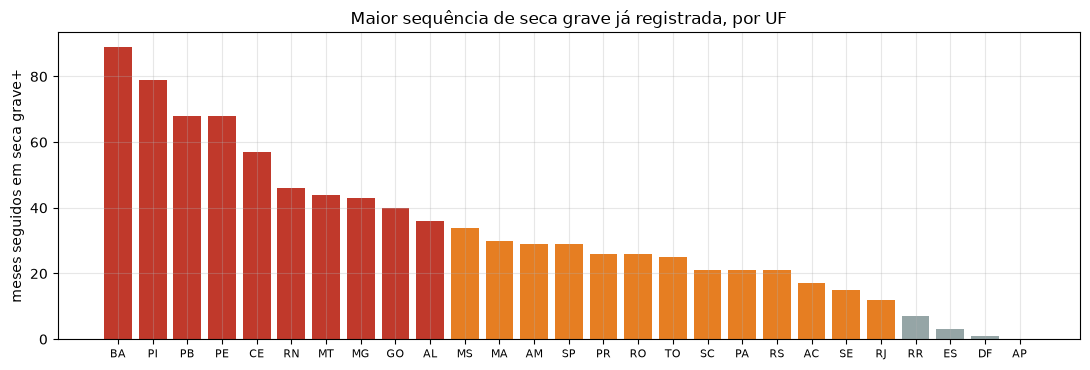

In [21]:
persistencia = d.groupby("sigla_uf")["meses_consecutivos_S2plus"].max().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 3.8))
cores = ["#C0392B" if v >= 36 else "#E67E22" if v >= 12 else "#95A5A6" for v in persistencia.values]
ax.bar(range(len(persistencia)), persistencia.values, color=cores)
ax.set_xticks(range(len(persistencia)), persistencia.index, fontsize=8)
ax.set_ylabel("meses seguidos em seca grave+")
ax.set_title("Maior sequência de seca grave já registrada, por UF")
fig.tight_layout()
plt.show()

A **Bahia lidera com 89 meses seguidos** — mais de sete anos ininterruptos com alguma área em
seca grave. PI, PB, PE e CE vêm logo atrás. Como os estados do Norte só entraram no Monitor
depois de 2022, seus números baixos medem sobretudo **tempo de observação curto**, não ausência
de seca. Comparar persistência entre UFs sem considerar a data de entrada é enganoso.

In [22]:
NORDESTE = ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"]

comparacao = pd.DataFrame(
    {
        "todas as UFs monitoradas": d.groupby("ano")["severidade_media"].mean(),
        "só as 9 do NE (painel fixo)": d[d["sigla_uf"].isin(NORDESTE)].groupby("ano")["severidade_media"].mean(),
        "n_ufs_no_ano": d.groupby("ano")["sigla_uf"].nunique(),
    }
)
comparacao.round(2)

,todas as UFs monitoradas,só as 9 do NE (painel fixo),n_ufs_no_ano
ano,,,
2015,2.87,2.87,9
2016,3.37,3.37,9
2017,2.95,2.95,9
2018,2.18,2.22,10
2019,1.61,1.68,12
2020,1.22,1.02,20
2021,1.69,1.56,21
2022,1.02,0.51,24
2023,0.79,0.67,27


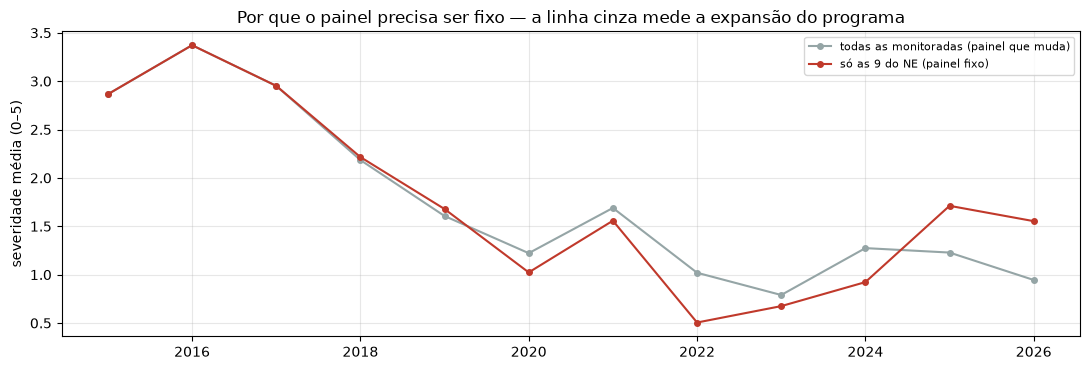

In [23]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(comparacao.index, comparacao["todas as UFs monitoradas"], marker="o", ms=4, color="#95A5A6", label="todas as monitoradas (painel que muda)")
ax.plot(comparacao.index, comparacao["só as 9 do NE (painel fixo)"], marker="o", ms=4, color="#C0392B", label="só as 9 do NE (painel fixo)")
ax.set_ylabel("severidade média (0–5)")
ax.legend(fontsize=8)
ax.set_title("Por que o painel precisa ser fixo — a linha cinza mede a expansão do programa")
fig.tight_layout()
plt.show()

Aqui está a armadilha, demonstrada. Até 2017 as duas linhas são **idênticas** — o painel era o
Nordeste e nada mais. Elas se separam conforme o programa cresce, e a separação muda de sinal:

* **2022**: a cinza marca 1,02 e a vermelha, 0,51. O Nordeste estava no seu melhor momento de
  toda a série, mas a média nacional parece **duas vezes pior** — porque naquele ano havia seca
  no Centro-Sul, que só entrou no painel em 2020.
* **2025**: o sinal se inverte. A vermelha (1,71) passa a cinza (1,23) — o Nordeste voltou a
  secar enquanto o resto do país estava mais úmido.

O ponto não é que a expansão sempre puxa a média para baixo; é que a linha cinza **mistura
mudança de clima com mudança de amostra**, e o efeito pode ir em qualquer direção. Em 2022 ela
exagera a seca do NE; em 2025 ela a esconde.

Só a linha vermelha, com o mesmo grupo de 9 UFs do começo ao fim, mostra o ciclo real: pico em
**2016 (3,37)**, mínimo em **2022 (0,51)**, retomada em 2025 (1,71).

Para o T-024, isso significa que a junção com preços precisa ou restringir a janela a 2024+
(nacional), ou restringir o conjunto de UFs (Nordeste desde 2015), ou tratar a entrada de cada UF
explicitamente — nunca calcular médias nacionais sobre a série inteira.

---
## 6. Redundância: cinco faixas para o mesmo fenômeno

Sendo cumulativas por construção, as colunas `pct_area_*` são necessariamente correlacionadas. A
questão é quanto.

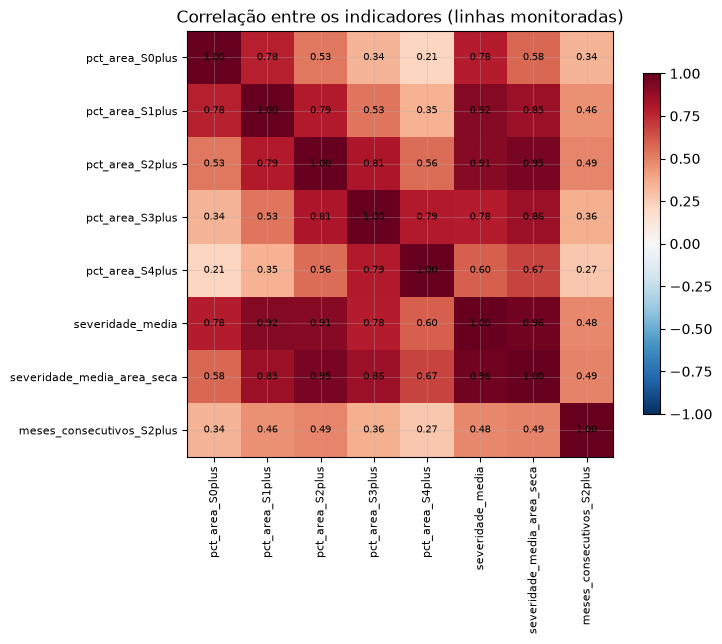

In [24]:
corr = d[MEDIDAS].astype("float64").corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(MEDIDAS)), MEDIDAS, rotation=90, fontsize=8)
ax.set_yticks(range(len(MEDIDAS)), MEDIDAS, fontsize=8)
for i in range(len(MEDIDAS)):
    for j in range(len(MEDIDAS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlação entre os indicadores (linhas monitoradas)")
fig.tight_layout()
plt.show()

Três leituras:

* **`severidade_media` é quase um resumo suficiente.** Correlaciona 0,92 com S1plus, 0,91 com
  S2plus e 0,96 com `severidade_media_area_seca`. Ela foi construída para isso — é a média
  ponderada das faixas exclusivas.
* **As faixas adjacentes são fortemente colineares** (S2↔S3 = 0,81; S3↔S4 = 0,79), mas as
  **extremas não** (S0↔S4 = apenas **0,21**). Ter 100% do estado em seca fraca diz muito pouco
  sobre haver seca excepcional. As pontas da escala carregam informação distinta, então usar S0
  e S4 juntos não é redundância — usar S2, S3 e S4 juntos praticamente é.
* **`meses_consecutivos_S2plus` é a coluna mais independente** de todas: no máximo 0,49 contra
  qualquer outra. E isso faz sentido — ela é a única que mede **tempo**, não área. Duas UFs podem
  ter a mesma área seca hoje sendo que uma está assim há 2 meses e a outra há 4 anos. Para efeito
  sobre safra e preço, essa distinção é provavelmente o que mais importa.

In [25]:
pares = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("pares mais redundantes:")
print(pares.sort_values(ascending=False).head(5).to_string())
print("\npares menos redundantes:")
print(pares.sort_values().head(5).to_string())

pares mais redundantes:
severidade_media  severidade_media_area_seca   0.96
pct_area_S2plus   severidade_media_area_seca   0.95
pct_area_S1plus   severidade_media             0.92
pct_area_S2plus   severidade_media             0.91
pct_area_S3plus   severidade_media_area_seca   0.86

pares menos redundantes:
pct_area_S0plus  pct_area_S4plus             0.21
pct_area_S4plus  meses_consecutivos_S2plus   0.27
pct_area_S0plus  pct_area_S3plus             0.34
                 meses_consecutivos_S2plus   0.34
pct_area_S1plus  pct_area_S4plus             0.35


---
## O que fica para as próximas etapas

| Ponto | Consequência |
|---|---|
| Grid completo 27 × 138, sem duplicata | O que falta é valor, não linha; a junção do T-024 não teme linha ausente |
| **36% das linhas não são monitoradas** — a UF não estava no programa | `NaN` ≠ "sem seca". Filtrar por `monitorado`, nunca imputar zero |
| Monitoramento começa com **9 UFs do NE em 2015** e só é nacional em **2024** | Média nacional sobre a série inteira mede a expansão do programa, não o clima |
| Painel fixo do NE mostra o ciclo real: pico 3,37 em 2016, mínimo 0,51 em 2022 | Comparar anos exige painel fixo ou janela 2024+ |
| SE tem exatamente **1 mês faltando** (2023-04) no meio da série | Único buraco real; tratar como dado ausente pontual |
| `ano_mes` é **texto** `YYYY-MM`; **2026 vai só até junho** | Converter para `datetime`; não comparar 2026 com anos completos |
| Faixas são **cumulativas**: S0 ⊇ S1 ⊇ S2 ⊇ S3 ⊇ S4, com 0 violações em 2.368 linhas | Nunca somar as cinco colunas — daria muito mais que 100% |
| `pct_area_S4plus` é **zero em 86,8% dos meses**, mediana 0 | Variável de evento raro, não contínua; média descreve mal |
| `pct_area_S0plus` satura em **100% em 28,4% dos meses** | No teto ela não discrimina; usar as faixas severas para medir intensidade |
| Distribuições bimodais: pilha em 0 e pilha em 100 | Estado tende a estar inteiro seco ou inteiro livre |
| `severidade_media_area_seca` é `NaN` ⟺ não há área seca | Correto por construção. Preferir `severidade_media`, que tem 0 bem definido |
| `inconsistente` é `False` em todas as linhas | A violação conhecida (MA 2014-11) está fora da janela |
| `severidade_media` correlaciona ≥ 0,91 com S1+ e S2+ | Resumo quase suficiente; dispensa carregar as cinco faixas |
| `meses_consecutivos_S2plus` correlaciona no máx. 0,49 com as demais | A única que mede **persistência**; candidata forte a feature independente |
| Persistência baixa no Norte reflete entrada tardia, não ausência de seca | Não comparar persistência entre UFs sem normalizar pelo tempo de observação |